# HW 2. Citi Bike DWH: model, ELT pipeline and analysis

This notebook goes with [`report.md`](report.md). It reads the published mart of the
local DWH and shows how 4,083 raw trip rows become one table that answers a station
planner's questions.

| | |
|---|---|
| Source | Citi Bike system data, Jersey City / Hoboken, `JC-202608-citibike-tripdata.csv.zip` ([license](https://citibikenyc.com/data-sharing-policy)) |
| Control slice | trips started 2026-08-03 to 2026-08-09 at six stations, 4,083 trips |
| Consumer | a station operations planner of the JC / Hoboken network |
| Questions | (1) How many trips start at each station per day, and how does the member / casual mix shift between weekdays and the weekend? (2) How does trip duration differ by area and rider type? |
| Stack | PostgreSQL 16.9, dbt-core 1.12.5, Apache Airflow 3.3.2, all in Docker |

To run it yourself: `docker compose up -d` in this directory, then run all cells. The
notebook only reads the DWH and never writes to it, so it cannot disturb a publication.
If the stand is not running it still executes end to end: the analysis falls back to
recomputing the same table from the committed input slice, and only the three sections that
inspect the warehouse itself say so.

## 0. Connecting to the warehouse

The queries below read the same PostgreSQL instance the Airflow DAG publishes to
(`localhost:5433`, database `dwh`). The credentials are the local teaching values from
`docker-compose.yml`, and there are no external secrets in this project. The cell reports
which mode the run is in, and nothing below it fails if the stand happens to be down.

In [21]:
import os, warnings, zipfile
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# pandas prefers SQLAlchemy engines; a psycopg2 connection is fine for read-only queries.
warnings.filterwarnings("ignore", message=".*DBAPI2.*")
pd.set_option("display.max_rows", 50, "display.width", 120)

CONN = dict(host=os.environ.get("DWH_HOST", "127.0.0.1"),
            port=int(os.environ.get("DWH_PORT", "5433")),
            dbname="dwh", user="dwh", password="dwh")

def q(sql, **params):
    """Run a read-only query against the DWH and return a DataFrame."""
    with psycopg2.connect(connect_timeout=3, **CONN) as conn:
        return pd.read_sql_query(sql, conn, params=params or None)

try:
    DWH_ONLINE = True
    print("mode: LIVE DWH -", q("select version()").iloc[0, 0].split(",")[0])
except Exception as e:
    DWH_ONLINE = False
    print("mode: OFFLINE - the stand is not running, so the figures below are recomputed\n"
          "      from the committed input slice with the same rules the dbt models use.\n"
          f"      ({type(e).__name__})")

mode: LIVE DWH - PostgreSQL 16.9 (Debian 16.9-1.pgdg130+1) on aarch64-unknown-linux-gnu


## 1. What arrives: the raw layer

`raw.trips` holds the source rows as delivered, every column as text, plus batch metadata:
which system sent it, from which file and batch, and when.

Keeping raw untouched is what makes the pipeline re-runnable. If a typing rule or a
business definition turns out to be wrong, history can be recomputed from these rows
without fetching the source again.

In [22]:
OFFLINE_NOTE = "(needs the stand: docker compose up -d - this cell inspects the warehouse itself)"

if DWH_ONLINE:
    display(q("""
    select source_system, source_file, count(*) as rows, min(loaded_at)::timestamp(0) as loaded_at
    from raw.trips   group by 1, 2
    union all
    select source_system, source_file, count(*), min(loaded_at)::timestamp(0)
    from raw.stations group by 1, 2
    order by loaded_at, source_file
    """))
else:
    print(OFFLINE_NOTE)

,source_system,source_file,rows,loaded_at
0,citibike_jc,scenarios/zero_duration.csv,1,2026-09-23 21:19:54
1,citibike_jc,slice/stations_2026-08.csv,108,2026-09-23 21:19:54
2,citibike_jc,slice/trips_2026-08-03_2026-08-09.csv,4083,2026-09-23 21:19:54


## 2. The model: one fact, two dimensions

Grain. One row of `dds.fact_trip` is one completed trip from one source system. The
key is `(source_system, ride_id)`, not `ride_id` alone. That is what lets a partner feed
reuse the same local ids without two different trips merging into one.

| Table | Key | Links to the fact | Cardinality |
|---|---|---|---|
| `dds.dim_date` | `date_key` (yyyymmdd) | `fact_trip.date_key` | 1 date : N trips |
| `dds.dim_station` | `station_key` = md5(`station_id`, `valid_from`) | `fact_trip.station_key` | 1 version : N trips |
| `dds.fact_trip` | `trip_key` = `source_system:ride_id` | | 1 : 1 with the source ride |
| `mart.daily_station_trips` | date, source, station, rider type | aggregates the fact | N trips : 1 row |

Why a star. The consumer asks for counts and sums by day and by station attributes.
A star answers that with one join per dimension and re-aggregates correctly. A Data Vault
or a normalised operational model would be the right choice for integrating many sources
with changing entities, which is not the case here.

Why `dim_station` keeps history (SCD 2). Stations get renamed and moved. If the
dimension were overwritten in place, yesterday's report would change when a station is
renamed today. Each version carries a `[valid_from, valid_to)` interval and the fact joins
the version valid on the trip's start date. Trip attributes are not versioned: a corrected
trip replaces the previous one, which is what the late correction case relies on.

The row counts below show the funnel. On a clean batch staging removes nothing, because
every source row is one trip, so `raw`, `stg` and `fact` carry the same 4,083 rows, which then
collapse into 84 mart rows (7 days × 6 stations × 2 rider types). The deduplication rule is
still doing work: it is what keeps that number at 4,083 when the same ride is delivered
twice, which is exactly the first diagnostic case below. If a scenario batch happens to be
loaded, `raw` carries its extra rows here too.

In [23]:
LAYER_SQL = """
select 'raw.trips'    as table_name, count(*) as rows, 'source rows as delivered' as note from raw.trips
union all select 'raw.stations',      count(*), 'station reference versions'        from raw.stations
union all select 'stg.stg_trips',     count(*), 'typed, one row per (source, ride)' from stg.stg_trips
union all select 'dds.dim_date',      count(*), 'calendar of the slice'             from dds.dim_date
union all select 'dds.dim_station',   count(*), 'station versions (SCD2)'           from dds.dim_station
union all select 'dds.fact_trip',     count(*), 'one row = one completed trip'      from dds.fact_trip
union all select 'mart_candidate.daily_station_trips', count(*), 'built by dbt, then tested' from mart_candidate.daily_station_trips
union all select 'mart.daily_station_trips',           count(*), 'PUBLISHED - what the consumer reads' from mart.daily_station_trips
"""

if DWH_ONLINE:
    display(q(LAYER_SQL))
else:
    print(OFFLINE_NOTE)

,table_name,rows,note
0,raw.trips,4084,source rows as delivered
1,raw.stations,108,station reference versions
2,stg.stg_trips,4084,"typed, one row per (source, ride)"
3,dds.dim_date,7,calendar of the slice
4,dds.dim_station,108,station versions (SCD2)
5,dds.fact_trip,4084,one row = one completed trip
6,mart_candidate.daily_station_trips,84,"built by dbt, then tested"
7,mart.daily_station_trips,84,PUBLISHED - what the consumer reads


## 3. How it is published

dbt builds the mart into `mart_candidate` and runs 34 tests against it: key
uniqueness, fact→dimension relationships, accepted values, a business rule
(`ended_at > started_at`), two SCD2 rules, and a reconciliation of mart totals against the
fact. Only if every test passes does the Airflow task `publish` copy the interval into
`mart` inside a single transaction and record a checksum.

Because of that separation a failing test cannot change what the consumer sees. The log
below has one row per successful publication, with a checksum over keys, rows and measures
rather than `count(*)` alone, which would miss a changed value.

The `baseline` checksum repeats across separate runs, so the pipeline is idempotent.
`late_fix` has a different checksum because a corrected trip changed a measure.
`second_source` publishes 86 rows instead of 84 because the partner feed adds two rows.
Runs that failed their tests do not appear here at all.

In [24]:
if DWH_ONLINE:
    display(q("""
    select publication_id, scenario, rows_published, checksum,
           published_at::timestamp(0) as published_at
    from ops.publications order by publication_id
    """))
else:
    print(OFFLINE_NOTE)

,publication_id,scenario,rows_published,checksum,published_at
0,1,baseline,84,32b30791faf47178a5a1f6c8e9299be4,2026-09-18 20:50:16
1,2,baseline,84,32b30791faf47178a5a1f6c8e9299be4,2026-09-18 21:06:23
2,3,baseline,84,32b30791faf47178a5a1f6c8e9299be4,2026-09-18 21:06:48
3,4,duplicate,84,32b30791faf47178a5a1f6c8e9299be4,2026-09-18 21:07:12
4,5,late_fix,84,97185e302636dbbf39e8d5feb83b6fcc,2026-09-18 21:07:40
5,6,late_fix,84,97185e302636dbbf39e8d5feb83b6fcc,2026-09-18 21:08:08
6,7,second_source,86,f6a6cebb960bff37760b17b141b4990d,2026-09-18 21:08:29
7,8,baseline,84,32b30791faf47178a5a1f6c8e9299be4,2026-09-18 21:09:47
8,9,late_fix,84,97185e302636dbbf39e8d5feb83b6fcc,2026-09-18 23:03:14
9,10,baseline,84,32b30791faf47178a5a1f6c8e9299be4,2026-09-23 20:22:05


### Chart style

One cell sets the style for every figure: light surface, quiet grid and axes, text in
grey tones rather than series colours, and a fixed colour order so a station keeps its
colour from chart to chart. The palette was checked for colour-blind separation, and each
chart comes with its own data table.

In [25]:
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"   # titles
INK_2     = "#52514e"   # axis labels
MUTED     = "#898781"   # ticks
GRID      = "#e1e0d9"
AXIS      = "#c3c2b7"
SERIES    = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.labelsize": 10,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 9, "legend.labelcolor": INK_2,
    "lines.linewidth": 2, "lines.markersize": 6,
})

def tidy(ax, xgrid=False):
    """Recessive chrome: no top/right spines, horizontal grid only by default."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.8)
    ax.grid(axis="y")
    ax.grid(axis="x", visible=xgrid)
    return ax

print("style ready")

style ready


### Where the numbers come from

The notebook uses the published mart in PostgreSQL. If the stand is not running it
recomputes the same table from the committed slice with the rules the dbt models use:
whole seconds for a duration, the station version valid on the start date, one row per day,
station and rider type. The mode is printed above. The analysis is the same either way;
only sections 1, 3 and 6, which look at the warehouse itself, need a live connection.

In [26]:
SLICE_TRIPS   = "data/slice/trips_2026-08-03_2026-08-09.csv"
SLICE_STATION = "data/slice/stations_2026-08.csv"

def mart_from_slice():
    """Rebuild mart.daily_station_trips from the committed slice, in pandas."""
    t = pd.read_csv(SLICE_TRIPS)
    s = pd.read_csv(SLICE_STATION)[["station_id", "station_name", "area"]]
    t["started_at"] = pd.to_datetime(t.started_at)
    t["ended_at"] = pd.to_datetime(t.ended_at)
    # floor(), not round(): the source carries milliseconds - see section 5.
    t["duration_sec"] = ((t.ended_at - t.started_at).dt.total_seconds()).astype(int)
    t["calendar_date"] = t.started_at.dt.strftime("%Y-%m-%d")
    out = (t.groupby(["calendar_date", "start_station_id", "member_casual"], as_index=False)
             .agg(trips=("ride_id", "count"),
                  electric_trips=("rideable_type", lambda x: int((x == "electric_bike").sum())),
                  total_duration_sec=("duration_sec", "sum"))
             .rename(columns={"start_station_id": "station_id"}))
    out = out.merge(s, on="station_id", how="left")
    out["avg_duration_sec"] = (out.total_duration_sec / out.trips).round(1)
    out["is_weekend"] = pd.to_datetime(out.calendar_date).dt.dayofweek >= 5   # Mon=0 .. Sun=6
    out["source_system"] = "citibike_jc"
    return out

def load_mart():
    if DWH_ONLINE:
        return q("""
            select calendar_date::text, is_weekend, source_system, station_id, station_name,
                   area, member_casual, trips, electric_trips, total_duration_sec, avg_duration_sec
            from mart.daily_station_trips order by calendar_date, station_id, member_casual
        """)
    return mart_from_slice()

mart = load_mart()
print(f"{len(mart)} mart rows, {mart.trips.sum():,} trips, "
      f"{mart.total_duration_sec.sum():,} seconds")
mart.head(4)

84 mart rows, 4,083 trips, 2,113,343 seconds


,calendar_date,is_weekend,source_system,station_id,station_name,area,member_casual,trips,electric_trips,total_duration_sec,avg_duration_sec
0,2026-08-03,False,citibike_jc,HB103,South Waterfront Walkway - Sinatra Dr & 1 St,Hoboken,casual,15,7,14727,981.8
1,2026-08-03,False,citibike_jc,HB103,South Waterfront Walkway - Sinatra Dr & 1 St,Hoboken,member,42,18,18459,439.5
2,2026-08-03,False,citibike_jc,HB107,Hudson Pl & Hoboken Terminal,Hoboken,casual,4,2,1937,484.3
3,2026-08-03,False,citibike_jc,HB107,Hudson Pl & Hoboken Terminal,Hoboken,member,14,7,4845,346.1


## 4. Answering the planner's questions

### 4.1 How busy is each station, day by day?

The first question is simply where and when do rides begin. Six stations over seven
days, one line each, so a station's weekly rhythm stays visible instead of being averaged away.

In [27]:
jc = mart[mart.source_system == "citibike_jc"].copy()
jc["member_trips"] = jc.trips.where(jc.member_casual == "member", 0)
daily = (jc.groupby(["calendar_date", "station_id", "station_name", "area", "is_weekend"],
                    as_index=False)
           .agg(trips=("trips", "sum"), member_trips=("member_trips", "sum"),
                total_duration_sec=("total_duration_sec", "sum")))
daily["member_pct"] = 100 * daily.member_trips / daily.trips

by_station = daily.pivot(index="calendar_date", columns="station_id", values="trips")
by_station.loc["total"] = by_station.sum()
by_station

station_id,HB103,HB107,HB609,JC009,JC109,JC115
calendar_date,,,,,,
2026-08-03,57,18,94,50,59,128
2026-08-04,79,82,155,82,87,213
2026-08-05,75,85,120,65,67,165
2026-08-06,85,89,135,90,89,204
2026-08-07,54,65,97,83,99,157
2026-08-08,89,79,93,89,84,184
2026-08-09,81,60,105,66,81,144
total,520,478,799,525,566,1195


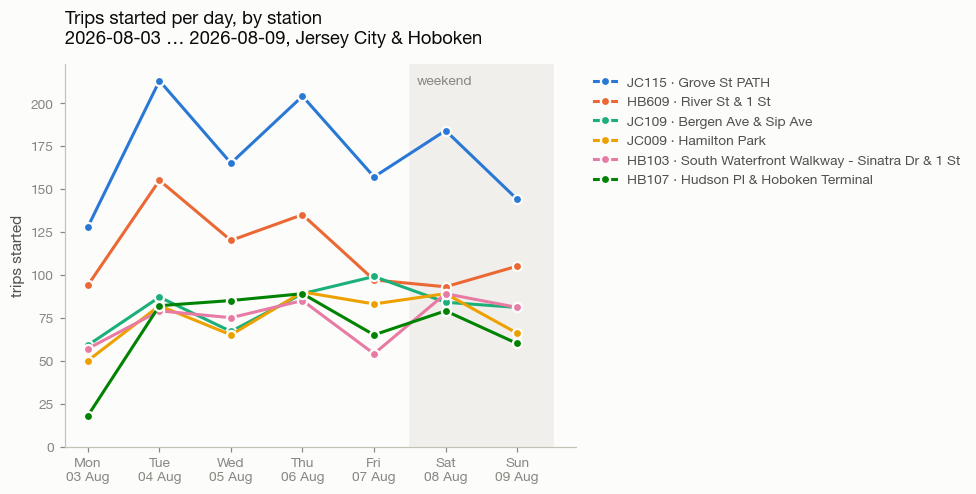

In [28]:
pivot = daily.pivot(index="calendar_date", columns="station_id", values="trips")
order = pivot.sum().sort_values(ascending=False).index          # busiest first -> stable colours
labels = {s: f"{s} · {daily.loc[daily.station_id == s, 'station_name'].iloc[0]}" for s in order}
days = list(pivot.index)
weekend = [i for i, d in enumerate(days) if pd.Timestamp(d).isoweekday() >= 6]

fig, ax = plt.subplots(figsize=(9, 4.6))
# Weekend band first, so it sits behind the data.
ax.axvspan(min(weekend) - 0.5, max(weekend) + 0.5, color="#f0efec", zorder=0)
ax.text(min(weekend) - 0.4, 0.97, "weekend", color=MUTED, fontsize=9, va="top",
        transform=ax.get_xaxis_transform())   # x in data coords, y in axes coords

for i, s in enumerate(order):
    ax.plot(range(len(days)), pivot[s], marker="o", color=SERIES[i],
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=labels[s], zorder=3)

tidy(ax)
ax.set_xticks(range(len(days)))
ax.set_xticklabels([pd.Timestamp(d).strftime("%a\n%d %b") for d in days])
ax.set_ylabel("trips started")
ax.set_ylim(0, None)
ax.set_title("Trips started per day, by station\n2026-08-03 … 2026-08-09, Jersey City & Hoboken")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), handlelength=1.6)
plt.tight_layout()
plt.show()

What it shows. Grove St PATH (`JC115`) is the busiest origin every day, with 1,195
trips over the week against 799 at the next station, so 50 % more traffic. Through the
working week the six stations rise and fall together: Tuesday is the peak at 698 trips,
Wednesday dips, Thursday recovers. That points to a network-wide driver such as weather or
the weekday rhythm rather than anything station-specific. Monday the 3rd is the quietest
day at 406 trips and the trough for four of the six stations.

At the weekend the lines separate. `JC115` and `HB609` stay well ahead while the four
smaller stations converge. For a planner this means `JC115` sets the daily demand, and on
weekdays the whole network needs attention on the same days.

### 4.2 Who rides, and how that changes at the weekend

Volume alone hides who is riding. Members are commuters on a subscription; casual riders
are visitors and occasional users. The mix is what tells the planner whether a day is a
commute day or a leisure day.

In [29]:
mix = (daily.groupby(["calendar_date", "area"])
            .agg(trips=("trips", "sum"), member_trips=("member_trips", "sum"))
            .reset_index())
mix["member_pct"] = 100 * mix.member_trips / mix.trips
mix_p = mix.pivot(index="calendar_date", columns="area", values="member_pct").round(1)
mix_p

area,Hoboken,Jersey City
calendar_date,,
2026-08-03,77.5,85.2
2026-08-04,72.8,83.8
2026-08-05,78.9,84.5
2026-08-06,69.3,78.9
2026-08-07,64.8,78.2
2026-08-08,56.7,65.5
2026-08-09,51.6,71.8


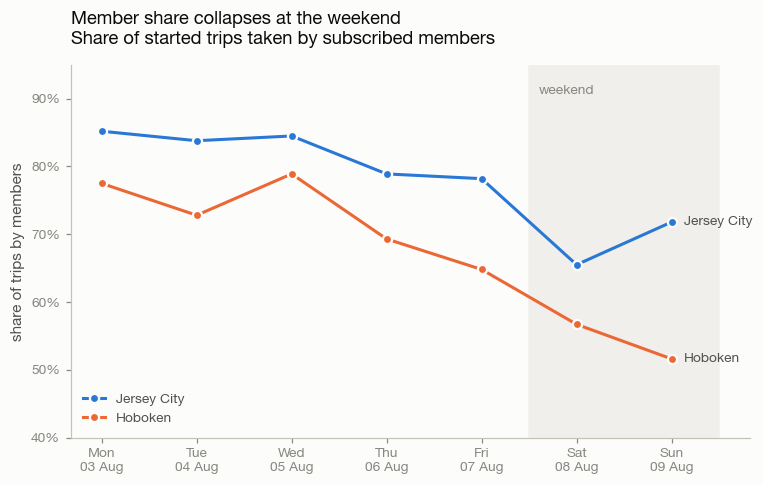

In [30]:
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.axvspan(min(weekend) - 0.5, max(weekend) + 0.5, color="#f0efec", zorder=0)
ax.text(min(weekend) - 0.4, 92, "weekend", color=MUTED, fontsize=9, va="top")

for i, area in enumerate(["Jersey City", "Hoboken"]):
    y = mix_p[area].values
    ax.plot(range(len(days)), y, marker="o", color=SERIES[i],
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=area, zorder=3)
    # Two series -> direct labels as well as a legend; identity never colour-alone.
    ax.annotate(area, (len(days) - 1, y[-1]), xytext=(8, 0), textcoords="offset points",
                color=INK_2, fontsize=9, va="center")

tidy(ax)
ax.set_xticks(range(len(days)))
ax.set_xticklabels([pd.Timestamp(d).strftime("%a\n%d %b") for d in days])
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylim(40, 95)
ax.set_ylabel("share of trips by members")
ax.set_title("Member share collapses at the weekend\nShare of started trips taken by subscribed members")
ax.legend(loc="lower left", handlelength=1.6)
plt.subplots_adjust(right=0.86)
plt.show()

In [31]:
# The same finding as one number per day type.
summary = (daily.assign(day_type=lambda d: d.is_weekend.map({True: "weekend", False: "weekday"}))
                .groupby("day_type", as_index=False)
                .agg(trips=("trips", "sum"), member_trips=("member_trips", "sum")))
summary["member_pct"] = (100 * summary.member_trips / summary.trips).round(1)
summary

,day_type,trips,member_trips,member_pct
0,weekday,2928,2276,77.7
1,weekend,1155,718,62.2


What it shows. Both areas hold a high member share through the working week, Jersey
City 78 to 85 % and Hoboken 65 to 79 %, and both fall at the weekend. Hoboken drops
furthest and keeps dropping: 56.7 % on Saturday and 51.6 % on Sunday, so by Sunday barely
half its trips are commuters. Jersey City dips to 65.5 % on Saturday and recovers to
71.8 % on Sunday. Over the week the member share falls from 77.7 % on weekdays to 62.2 %
at the weekend.

The two areas move in parallel but at different levels. Hoboken draws proportionally more
casual riders on every day of the week, and the weekend widens that gap rather than
creating it.

### 4.3 How long is a ride?

Duration is the second measure the mart carries. It is aggregated as
`sum(total_duration_sec) / sum(trips)`, never as a mean of daily means, which would weight
a quiet Monday the same as a busy Friday.

In [32]:
dur = (jc.assign(day_type=lambda d: d.is_weekend.map({True: "weekend", False: "weekday"}))
         .groupby(["area", "member_casual", "day_type"], as_index=False)
         .agg(trips=("trips", "sum"),
              total_duration_sec=("total_duration_sec", "sum"),
              electric_trips=("electric_trips", "sum")))
dur["avg_minutes"] = (dur.total_duration_sec / dur.trips / 60).round(1)
dur["electric_pct"] = (100 * dur.electric_trips / dur.trips).round(1)
dur = dur[["area", "member_casual", "day_type", "trips", "avg_minutes", "electric_pct"]]
dur

,area,member_casual,day_type,trips,avg_minutes,electric_pct
0,Hoboken,casual,weekday,354,10.4,65.0
1,Hoboken,casual,weekend,232,16.5,60.8
2,Hoboken,member,weekday,936,6.9,62.6
3,Hoboken,member,weekend,275,9.6,64.0
4,Jersey City,casual,weekday,298,9.5,72.5
5,Jersey City,casual,weekend,205,15.3,72.2
6,Jersey City,member,weekday,1340,6.7,55.2
7,Jersey City,member,weekend,443,8.1,55.3


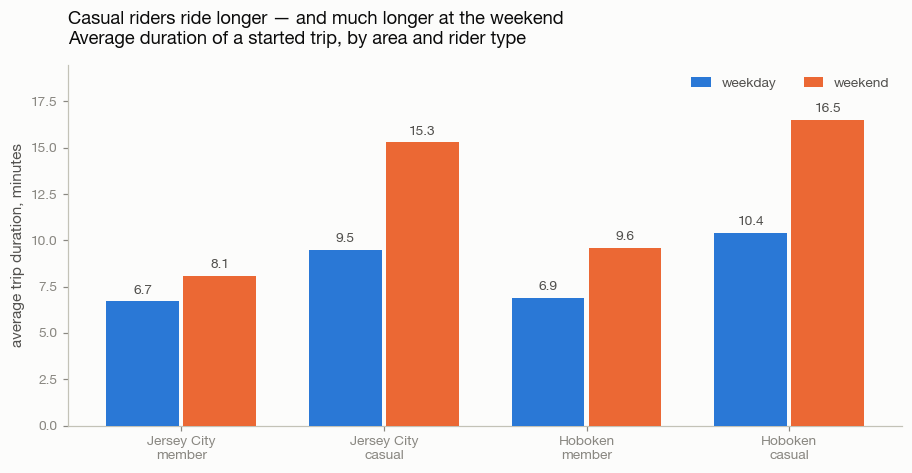

In [33]:
groups = [("Jersey City", "member"), ("Jersey City", "casual"),
          ("Hoboken", "member"), ("Hoboken", "casual")]
x = range(len(groups))
w = 0.38
vals = {dt: [float(dur[(dur.area == a) & (dur.member_casual == m) & (dur.day_type == dt)].avg_minutes.iloc[0])
             for a, m in groups] for dt in ("weekday", "weekend")}

fig, ax = plt.subplots(figsize=(8.4, 4.4))
for i, (dt, colour) in enumerate(zip(("weekday", "weekend"), SERIES[:2])):
    pos = [p - w/2 + i*w for p in x]
    # 2px surface gap between adjacent bars comes from width < slot.
    bars = ax.bar(pos, vals[dt], width=w - 0.02, color=colour, label=dt, zorder=3)
    ax.bar_label(bars, fmt="%.1f", padding=3, color=INK_2, fontsize=9)

tidy(ax)
ax.set_xticks(list(x))
ax.set_xticklabels([f"{a}\n{m}" for a, m in groups])
ax.set_ylabel("average trip duration, minutes")
ax.set_ylim(0, max(max(vals["weekend"]), max(vals["weekday"])) * 1.18)
ax.set_title("Casual riders ride longer — and much longer at the weekend\nAverage duration of a started trip, by area and rider type")
ax.legend(loc="upper right", ncols=2, handlelength=1.4)
plt.tight_layout()
plt.show()

What it shows. Two effects stack, and they are consistent in both areas:

- Rider type matters most. A casual trip runs about 42 to 51 % longer than a member trip
  on a weekday in the same area, and 72 to 89 % longer at the weekend.
- The weekend stretches every group, casual riders most. Hoboken casual trips go from 10.4
  to 16.5 minutes and Jersey City casual from 9.5 to 15.3, while member trips move only
  from 6.7 to 6.9 minutes up to 8.1 to 9.6.

With 4.2 this gives the planner a compact picture. Weekdays are short, dense, member
commuting. Weekends are fewer but much longer casual rides. Those are different jobs for
the same bikes: bike availability matters on weekday mornings, dock space and turnover at
the weekend.

## 5. Independent control

A pipeline that agrees with itself proves nothing, so this section recomputes one mart
cell from the original month file with pandas, a different tool and code path with no DWH
involved, and compares it with what was published.

The check found a real error. The first version of the model used
`extract(epoch ...)::integer`, which rounds the millisecond fraction, while the check
truncated it. The totals differed by 75 seconds. Duration is now `floor(...)` in
`stg_trips` and the two calculations agree.

In [34]:
DAY, STATION = "2026-08-05", "JC115"
ZIP = "data/JC-202608-citibike-tripdata.csv.zip"

HAVE_ZIP = os.path.exists(ZIP)
if not HAVE_ZIP:
    print(f"{ZIP} is not present - run `python3 data/make_slice.py` to fetch it. "
          "The comparison below is skipped.")
    control = None
else:
    with zipfile.ZipFile(ZIP) as z:
        name = [n for n in z.namelist() if n.endswith(".csv") and "__MACOSX" not in n][0]
        src = pd.read_csv(z.open(name))
    src["started_at"] = pd.to_datetime(src.started_at)
    src["ended_at"] = pd.to_datetime(src.ended_at)
    cell = src[(src.started_at.dt.strftime("%Y-%m-%d") == DAY) & (src.start_station_id == STATION)].copy()
    cell["duration_sec"] = (cell.ended_at - cell.started_at).dt.total_seconds().astype(int)

    control = (cell.groupby("member_casual")
                   .agg(trips=("ride_id", "count"),
                        electric_trips=("rideable_type", lambda s: int((s == "electric_bike").sum())),
                        total_duration_sec=("duration_sec", "sum"))
                   .reset_index())
    print(f"Recomputed from {os.path.basename(ZIP)} with pandas:")
    display(control)

data/JC-202608-citibike-tripdata.csv.zip is not present - run `python3 data/make_slice.py` to fetch it. The comparison below is skipped.


In [35]:
published = (mart[(mart.calendar_date == DAY) & (mart.station_id == STATION)
                  & (mart.source_system == "citibike_jc")]
             [["member_casual", "trips", "electric_trips", "total_duration_sec"]]
             .sort_values("member_casual").reset_index(drop=True))
print("Published in mart.daily_station_trips:" if DWH_ONLINE
      else "Recomputed from the committed slice (stand offline):")
display(published)

if control is None:
    print("\nNo comparison: the source zip was not available (see the cell above).")
else:
    comparison = published.merge(control, on="member_casual", suffixes=("_mart", "_source"))
    for col in ("trips", "electric_trips", "total_duration_sec"):
        comparison[f"{col}_match"] = comparison[f"{col}_mart"] == comparison[f"{col}_source"]
    checks = [c for c in comparison.columns if c.endswith("_match")]
    print("\nAll six values match:", bool(comparison[checks].all().all()))
    display(comparison[["member_casual"] + checks])

Published in mart.daily_station_trips:


,member_casual,trips,electric_trips,total_duration_sec
0,casual,20,14,9252
1,member,145,64,57115



No comparison: the source zip was not available (see the cell above).


## 6. The four diagnostic cases

Each case is a small change to the input, run through the same DAG from the same
baseline. The scenario files in `data/scenarios/` are synthetic: derived from real slice
rows and marked by their path. Task states and query output are in
[`evidence/runs.txt`](evidence/runs.txt).

| Case | What changed | Forecast | Observed | Why |
|---|---|---|---|---|
| Duplicate | one ride delivered twice, byte-identical | no extra fact; the cell and checksum stay put | raw 2 rows → staging 1 → fact 1; checksum identical to baseline | staging keeps one row per `(source_system, ride_id)`; `trip_key` is unique |
| History overlap | a second, also open version of station `JC115` | SCD2 tests fail; publication blocked | `scd2_dim_station_no_overlap` 1 row, `scd2_one_station_version_per_trip` 854, `unique_fact_trip_trip_key` 854; `publish` never ran | two open intervals make the fact join ambiguous: 1,708 fact rows for 854 trips |
| Late correction | an already-processed trip re-sent with `ended_at` +15 min | the past day changes; a repeat does not double it | duration 209 → 1,109 s, the day's member total 57,115 → 58,015 s; the rerun reproduced it exactly | the business date comes from `started_at`, so the fix lands in the right day; the newer version replaces the older |
| Second source | a partner feed re-using the same `ride_id` values | 3 extra facts, nothing merged | 4,083 `citibike_jc` + 3 `partner_feed`; each shared id has two facts on different stations | identity is `(source_system, ride_id)`, and the mart carries `source_system` |

The publication log in section 3 is the trace of these runs: `duplicate` published the
baseline checksum unchanged, `late_fix` a different one, `second_source` 86 rows, and the
two blocked scenarios left no publication at all.

In [36]:
# Each case is visible in the warehouse only while its batch is the loaded one, so what
# this shows depends on the last DAG run. The recorded output of every case is in
# evidence/runs.txt; the checksums in the publication log above are the durable trace.
if not DWH_ONLINE:
    print(OFFLINE_NOTE, "- see evidence/runs.txt for the recorded output")
else:
    loaded = q("select distinct source_file from raw.trips order by 1")
    print("batches currently in raw.trips:", ", ".join(loaded.source_file))
    shared = q("""
    select ride_id, count(*) as facts,
           string_agg(source_system || ' @ ' || start_station_id, '  |  ' order by source_system) as sources
    from dds.fact_trip
    group by ride_id having count(*) > 1
    order by ride_id
    """)
    if len(shared):
        print("\nSame ride_id delivered by two systems - kept apart as distinct facts:")
        display(shared)
    else:
        print("\nOnly the baseline batch is loaded, so no ride_id is shared between systems.")
        print("Trip identity is the pair, not the id alone:")
        display(q("""
        select source_system, count(*) as facts,
               min(trip_key) as example_trip_key
        from dds.fact_trip group by source_system order by 1
        """))

batches currently in raw.trips: scenarios/zero_duration.csv, slice/trips_2026-08-03_2026-08-09.csv

Only the baseline batch is loaded, so no ride_id is shared between systems.
Trip identity is the pair, not the id alone:


,source_system,facts,example_trip_key
0,citibike_jc,4084,citibike_jc:0004BA17E00DA9A6


## 7. What the pipeline guarantees, and what it does not

What the pipeline guarantees, as shown above:

- A repeat is free. The same input republishes the same keys, rows and measures. The
  baseline checksum is identical across separate runs, because the loader replaces a batch
  instead of appending, staging keeps one version per key, and `publish` replaces the
  interval.
- A bad batch cannot reach the consumer. 34 tests stand between the candidate and the
  published mart, and the two blocked scenarios left the previous publication untouched.
- The numbers are verifiable. An independent recount from the original file reproduces the
  published cell exactly.

Limitations:

- Uniqueness is not completeness. Every key test passes on a truncated file too. Only a
  row-count contract with the source would catch a missing day.
- "Latest loaded wins" trusts arrival order, not a version stamp from the source. A late
  redelivery of an old version would overwrite a newer one. The feed has no version field.
- Timestamps are local New York time without a zone, so the ambiguous hour at the autumn
  DST change would need handling. It does not occur in August.
- The dds layer is rebuilt in full every run. That is fine at 4,083 rows but not for a full
  month of 111,227 trips, where the fact would have to become incremental.
- Two of the four cases use synthetic rows, because the real feed has neither station
  versions nor a second system.
- The stand is a teaching one: `airflow standalone`, one PostgreSQL for both the DWH and
  the Airflow metadata, and local passwords in `docker-compose.yml`.